In [2]:
import pandas as pd
import numpy as np

In [7]:
df=pd.read_csv('/content/data.csv', encoding='latin1')

/tmp/ipykernel_932/791111619.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/data.csv', encoding='latin1')


In [8]:
print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (435742, 13)
  stn_code       sampling_date           state   location agency  \
0    150.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
1    151.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
2    152.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
3    150.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   
4    151.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
1                     Industrial Area  3.1   7.0   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date  
0                         NaN    NaN  1990-02-01  
1                         NaN    NaN  1990-02-01  
2                         NaN    NaN  1

In [9]:
#check missing vlues
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149481
type                             5393
so2                             34646
no2                             16233
rspm                            40222
spm                            237387
location_monitoring_station     27491
pm2_5                          426428
date                                7
dtype: int64


In [10]:
print("\nData types:")
print(df.dtypes)


Data types:
stn_code                        object
sampling_date                   object
state                           object
location                        object
agency                          object
type                            object
so2                            float64
no2                            float64
rspm                           float64
spm                            float64
location_monitoring_station     object
pm2_5                          float64
date                            object
dtype: object


In [12]:
 #Data cleaning
 # Parse date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract year and month
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# Fill missing pollutant values with city median
pollutants = ['so2', 'no2', 'rspm', 'spm']
for col in pollutants:
    if col in df.columns:
        df[col] = df.groupby('state')[col].transform(
            lambda x: x.fillna(x.median())
        )

# Drop rows still missing critical values
df.dropna(subset=['so2', 'no2', 'rspm'], inplace=True)

# Clean city and state names
df['location']  = df['location'].str.strip().str.title()
df['state'] = df['state'].str.strip().str.title()

# Create AQI composite score
df['aqi'] = (
    df['so2']  * 0.1 +
    df['no2']  * 0.1 +
    df['rspm'] * 0.6 +
    df['spm'].fillna(0) * 0.2
)

# Create AQI category
def aqi_category(val):
    if val <= 50:
        return 'Good'
    elif val <= 100:
        return 'Moderate'
    elif val <= 200:
        return 'Poor'
    else:
        return 'Hazardous'

df['aqi_category'] = df['aqi'].apply(aqi_category)

print("Cleaned shape:", df.shape)
print(df[['location','year','aqi','aqi_category']].head(10))
print(df['aqi_category'].value_counts())

Cleaned shape: (435739, 17)
    location    year    aqi aqi_category
0  Hyderabad  1990.0  83.42     Moderate
1  Hyderabad  1990.0  82.21     Moderate
2  Hyderabad  1990.0  84.67     Moderate
3  Hyderabad  1990.0  83.30     Moderate
4  Hyderabad  1990.0  82.42     Moderate
5  Hyderabad  1990.0  84.41     Moderate
6  Hyderabad  1990.0  83.45     Moderate
7  Hyderabad  1990.0  82.54     Moderate
8  Hyderabad  1990.0  83.92     Moderate
9  Hyderabad  1990.0  82.49     Moderate
aqi_category
Moderate     174886
Poor         164830
Good          60128
Hazardous     35895
Name: count, dtype: int64


In [14]:
 #SQL analysis
 import sqlite3

conn = sqlite3.connect("aqi_india.db")
df.to_sql("air_quality", conn, if_exists="replace", index=False)

# Most polluted cities
q1 = """
SELECT location,
       ROUND(AVG(aqi), 2) AS avg_aqi,
       COUNT(*) AS records
FROM air_quality
GROUP BY location
ORDER BY avg_aqi DESC
LIMIT 10
"""
print("=== Top 10 Most Polluted Cities ===")
print(pd.read_sql(q1, conn))

# Year-wise trend
q2 = """
SELECT year,
       ROUND(AVG(aqi), 2) AS avg_aqi
FROM air_quality
WHERE year IS NOT NULL
GROUP BY year
ORDER BY year
"""
print("\n=== Year-wise AQI Trend ===")
print(pd.read_sql(q2, conn))

# Monthly pattern
q3 = """
SELECT month,
       ROUND(AVG(aqi), 2) AS avg_aqi
FROM air_quality
WHERE month IS NOT NULL
GROUP BY month
ORDER BY month
"""
print("\n=== Monthly AQI Pattern ===")
print(pd.read_sql(q3, conn))

# Most polluted states
q4 = """
SELECT state,
       ROUND(AVG(aqi), 2) AS avg_aqi,
       COUNT(DISTINCT location) AS cities
FROM air_quality
GROUP BY state
ORDER BY avg_aqi DESC
LIMIT 10
"""
print("\n=== Most Polluted States ===")
print(pd.read_sql(q4, conn))

conn.close()

=== Top 10 Most Polluted Cities ===
           location  avg_aqi  records
0         Ghaziabad   231.45     2056
1         Allahabad   220.64     1718
2          Bareilly   218.61      760
3    West Singhbhum   207.22      151
4           Mathura   203.78       78
5  Noida, Ghaziabad   200.51       27
6             Delhi   198.22     8551
7            Kanpur   197.46     7545
8         Firozabad   196.73     2620
9           Lucknow   192.77     6194

=== Year-wise AQI Trend ===
      year  avg_aqi
0   1987.0   127.21
1   1988.0   114.94
2   1989.0   108.73
3   1990.0   113.04
4   1991.0   110.95
5   1992.0   101.46
6   1993.0   108.71
7   1994.0   111.55
8   1995.0   114.72
9   1996.0   114.29
10  1997.0   107.53
11  1998.0   112.41
12  1999.0   112.41
13  2000.0   105.45
14  2001.0   109.42
15  2002.0    98.65
16  2003.0   104.32
17  2004.0   111.27
18  2005.0   117.04
19  2006.0   114.34
20  2007.0   110.59
21  2008.0   117.69
22  2009.0   119.35
23  2010.0   112.42
24  2011.0   113.

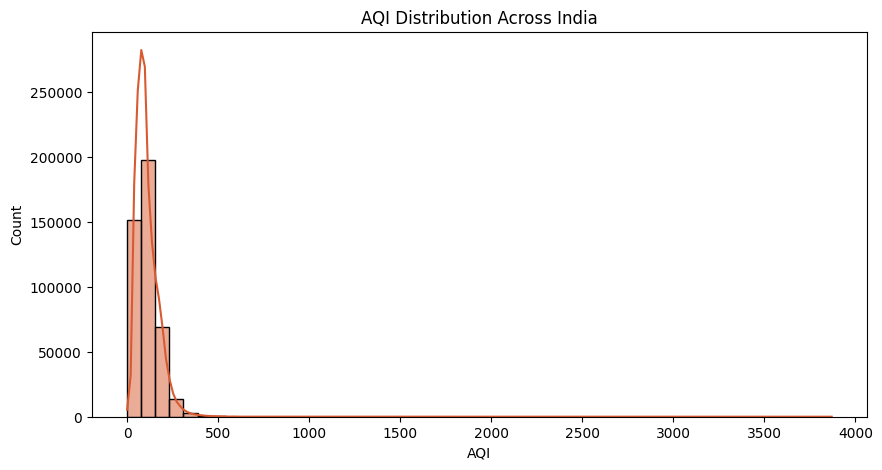

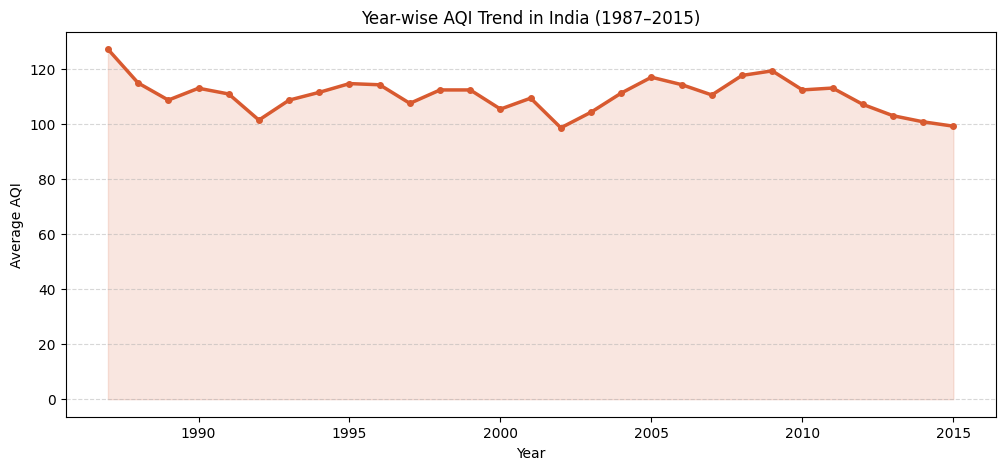

/tmp/ipykernel_932/3289585182.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='Reds_r')


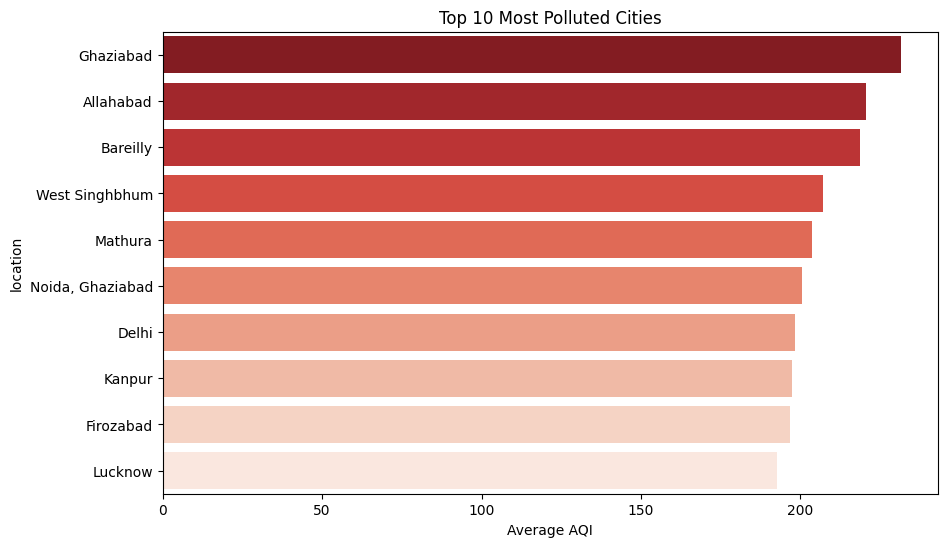

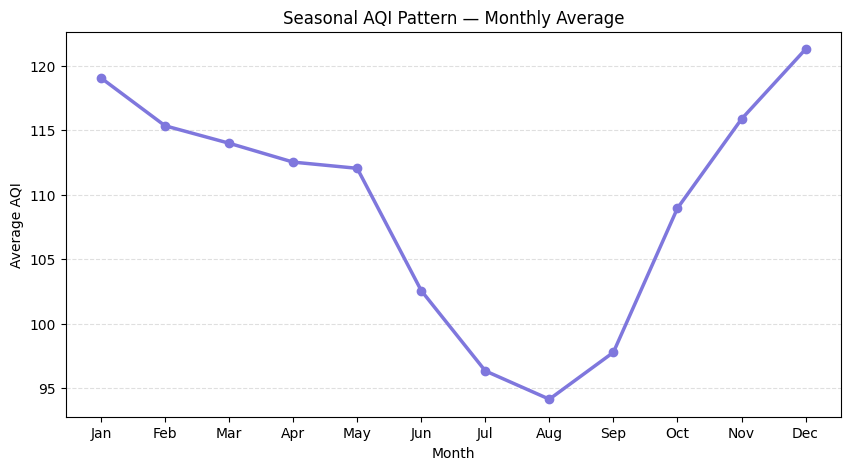

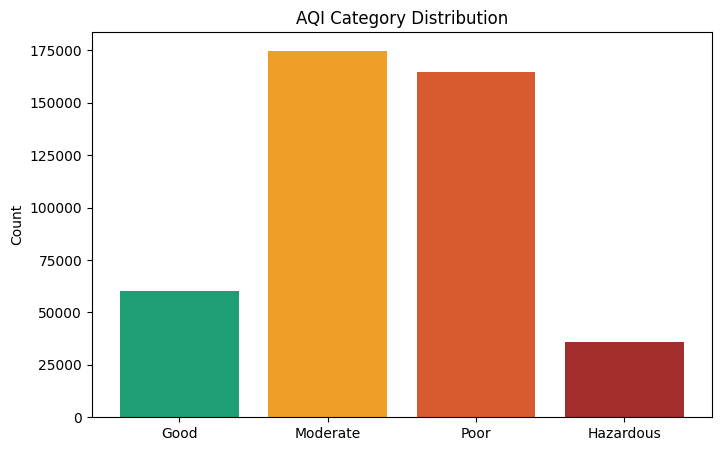

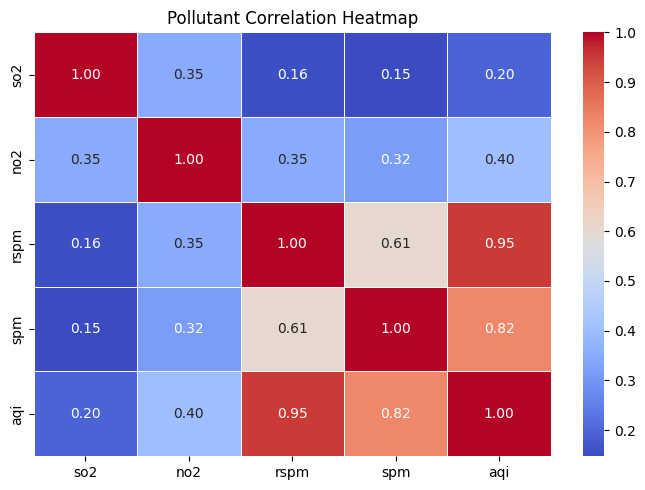

In [16]:
#Visualuzations
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: AQI distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['aqi'], bins=50, color='#D85A30', kde=True)
plt.title('AQI Distribution Across India')
plt.xlabel('AQI')
plt.savefig('aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Year-wise trend
yearly = df.groupby('year')['aqi'].mean()
plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly.values,
         color='#D85A30', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='#D85A30')
plt.title('Year-wise AQI Trend in India (1987–2015)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Top 10 polluted cities
top_cities = (df.groupby('location')['aqi']
                .mean()
                .sort_values(ascending=False)
                .head(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='Reds_r')
plt.title('Top 10 Most Polluted Cities')
plt.xlabel('Average AQI')
plt.savefig('top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 4: Monthly seasonal pattern
monthly = df.groupby('month')['aqi'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 5))
plt.plot(month_names, monthly.values,
         marker='o', color='#7F77DD', linewidth=2.5)
plt.title('Seasonal AQI Pattern — Monthly Average')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 5: AQI category breakdown
order  = ['Good','Moderate','Poor','Hazardous']
colors = ['#1D9E75','#EF9F27','#D85A30','#A32D2D']
plt.figure(figsize=(8, 5))
counts = [df[df['aqi_category']==c].shape[0] for c in order]
plt.bar(order, counts, color=colors)
plt.title('AQI Category Distribution')
plt.ylabel('Count')
plt.savefig('categories.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 6: Correlation heatmap
plt.figure(figsize=(7, 5))
cols = [c for c in ['so2','no2','rspm','spm','aqi'] if c in df.columns]
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Pollutant Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Accuracy: 88.67 %
              precision    recall  f1-score   support

        Good       0.85      0.84      0.85     12102
   Hazardous       0.89      0.85      0.87      7141
    Moderate       0.88      0.90      0.89     34932
        Poor       0.91      0.90      0.91     32972

    accuracy                           0.89     87147
   macro avg       0.88      0.87      0.88     87147
weighted avg       0.89      0.89      0.89     87147



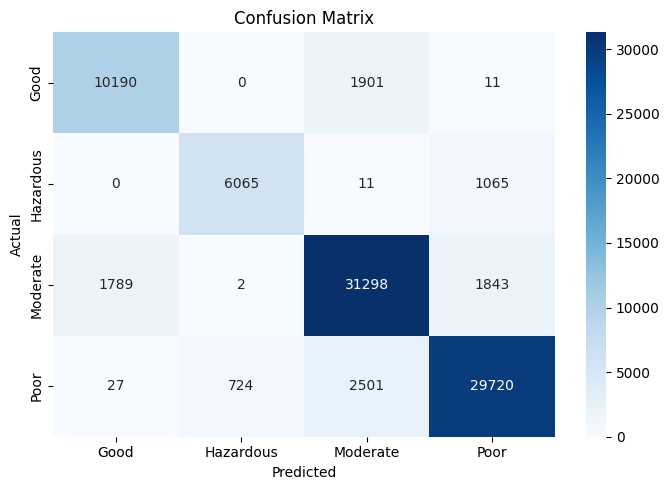

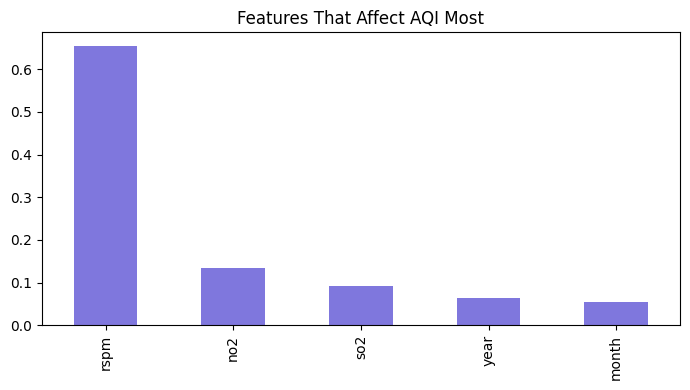

In [17]:
#ML model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df_model = df[['so2','no2','rspm','month','year','aqi_category']].copy()
df_model.dropna(inplace=True)

le = LabelEncoder()
df_model['aqi_enc'] = le.fit_transform(df_model['aqi_category'])

X = df_model[['so2','no2','rspm','month','year']]
y = df_model['aqi_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix plot
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
feat_imp = pd.Series(rf.feature_importances_,
                     index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
feat_imp.plot(kind='bar', color='#7F77DD')
plt.title('Features That Affect AQI Most')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
#export clean csv for powerbi
# Save clean data for Power BI
df.to_csv('clean_aqi.csv', index=False)
print("Saved! Rows:", len(df))

# Download to your laptop
from google.colab import files
files.download('clean_aqi.csv')

Saved! Rows: 435739


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#download in notebook
